# Allman latent-class MNAR simulation

## tl;dr

This notebook compares a complete-data oracle, MAR FIML, correctly specified and misspecified parametric selection likelihoods, and the proposed ridge-regularized saturated bridge. The primary targets are the measurement kernels $M_j$ and latent class proportion $p_f$. Across 100 replications, the proposed bridge has measurement-kernel bias $-0.0064$ and RMSE $0.0555$, compared with bias $0.0409$ and RMSE $0.0684$ for the misspecified selection likelihood.

## Model

Allman, Matias and Rhodes (2009, Section 3) define the $r$-class, $p$-feature model $M(r;\kappa_1,\ldots,\kappa_p)$. Their conditional-independence statement is: “conditional on $Z$, the $X_j$'s are independent random variables.” In their notation,

$$
P_i=\bigotimes_{j=1}^p p_{ij},\qquad
P=\sum_{i=1}^r \pi_iP_i.
$$

We use exactly this model class with $r=2$, $p=4$, and binary observed features $(W,Y_1,Y_2,Y_3)$. The latent class is denoted by $F$ in our paper. Since $p=4$ and $r=2$, the Bernoulli-product model satisfies the generic-identification bound in Allman et al. (2009, Corollary 5).

### What can and cannot be reproduced

The model definition and identification condition above come directly from Allman et al. The paper does not specify a numerical DGP, sample size, optimizer, bias, RMSE, standard error, or coverage result. Therefore the complete-data oracle below is our reproducibility benchmark; there is no Allman Monte Carlo table to match.

## Setup

1. `full_data_oracle`: full product-mixture likelihood before missingness.
2. `mar`: observed-data FIML using every observed item under ignorability.
3. `selection_likelihood_correct`: likelihood for $(W,Y_{obs},R)$ with the true selection interaction, integrating over latent classes and missing items while deliberately discarding the shadow $Z$.
4. `selection_likelihood_misspecified`: the same likelihood with the `Y1` main effect and interaction omitted while retaining MNAR dependence on `Yj`.
5. `proposed_saturated_bridge`: ridge-regularized, constrained inverse bridge with one parameter for each of the four binary pair-outcome cells, followed by bridge-weighted pairwise latent-model fitting.

The true selection intercepts are calibrated once from the population distribution. The shadow has a full-rank $4\times4$ conditional probability matrix over pair-outcome cells, so finite categorical B-completeness is built into the DGP.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "simulation":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from simulation.latent_mnar_sim import load_config, run_simulation

CONFIG_PATH = ROOT / "simulation" / "config.yml"
config = load_config(CONFIG_PATH)
print(config["model"]["name"])
print(f"n={config['sample_size']}, replications={config['replications']}")

M(r; kappa_1, ..., kappa_p)
n=500, replications=100


## Simulation

In [2]:
summary, overlap, bridge_diagnostics, replication_results = run_simulation(config)
results_dir = ROOT / "simulation" / "results"
results_dir.mkdir(exist_ok=True)
summary.to_csv(results_dir / "allman_summary.csv", index=False)
overlap.to_csv(results_dir / "allman_overlap.csv", index=False)
bridge_diagnostics.to_csv(results_dir / "allman_bridge_diagnostics.csv", index=False)
replication_results.to_csv(results_dir / "allman_replication_results.csv", index=False)
summary.round(4)

,method,M_bias,M_mean_absolute_error,p_f1_bias,mean_iterations,convergence_rate,M_RMSE,p_f1_RMSE
0,full_data_oracle,0.0031,0.0279,-0.0019,27.11,1.0,0.0351,0.0361
1,mar,-0.0496,0.0734,-0.0193,47.62,1.0,0.0966,0.0572
2,proposed_saturated_bridge,-0.0064,0.0436,-0.0029,44.96,1.0,0.0555,0.0517
3,selection_likelihood_correct,-0.0008,0.0415,0.0008,184.21,1.0,0.0544,0.0427
4,selection_likelihood_misspecified,0.0409,0.0552,0.0092,124.24,1.0,0.0684,0.0415


## Primary results

Bias and RMSE for $M_j$ and $p_f$ are the main simulation outputs.

In [3]:
summary[[
    "method", "M_bias", "M_mean_absolute_error", "M_RMSE",
    "p_f1_bias", "p_f1_RMSE"
]].round(4)

,method,M_bias,M_mean_absolute_error,M_RMSE,p_f1_bias,p_f1_RMSE
0,full_data_oracle,0.0031,0.0279,0.0351,-0.0019,0.0361
1,mar,-0.0496,0.0734,0.0966,-0.0193,0.0572
2,proposed_saturated_bridge,-0.0064,0.0436,0.0555,-0.0029,0.0517
3,selection_likelihood_correct,-0.0008,0.0415,0.0544,0.0008,0.0427
4,selection_likelihood_misspecified,0.0409,0.0552,0.0684,0.0092,0.0415


### Bias and RMSE comparison

The two panels report directional bias and RMSE for the measurement kernels and latent class proportion. A correctly specified selection likelihood may be more efficient; the proposed method is designed to avoid bias from parametric selection-link misspecification.

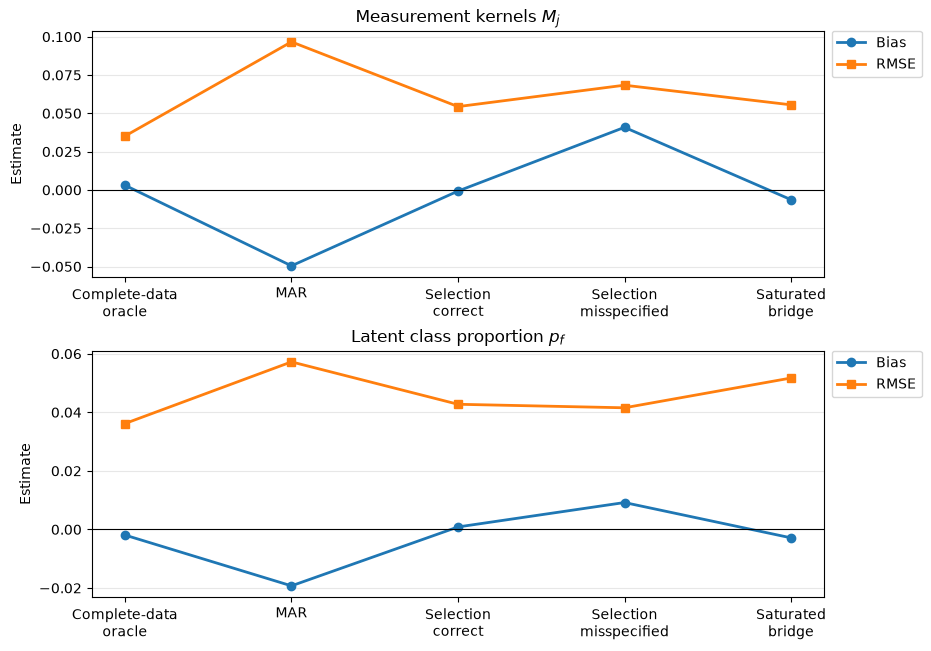

In [4]:
import matplotlib.pyplot as plt

method_order = [
    "full_data_oracle",
    "mar",
    "selection_likelihood_correct",
    "selection_likelihood_misspecified",
    "proposed_saturated_bridge",
]
method_labels = [
    "Complete-data\noracle",
    "MAR",
    "Selection\ncorrect",
    "Selection\nmisspecified",
    "Saturated\nbridge",
]
plot_data = summary.set_index("method").loc[method_order]
x = range(len(method_order))

fig, axes = plt.subplots(2, 1, figsize=(9.2, 6.4), constrained_layout=True)
panels = [
    ("Measurement kernels $M_j$", "M_bias", "M_RMSE"),
    ("Latent class proportion $p_f$", "p_f1_bias", "p_f1_RMSE"),
]
for axis, (title, bias_column, rmse_column) in zip(axes, panels):
    axis.plot(x, plot_data[bias_column], marker="o", linewidth=2, label="Bias")
    axis.plot(x, plot_data[rmse_column], marker="s", linewidth=2, label="RMSE")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_title(title)
    axis.set_ylabel("Estimate")
    axis.set_xticks(list(x), method_labels)
    axis.grid(axis="y", alpha=0.3)
    axis.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), borderaxespad=0)

figures_dir = ROOT / "simulation" / "figures"
figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "allman_bias_rmse_comparison.pdf", bbox_inches="tight")
fig.savefig(figures_dir / "allman_bias_rmse_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## Supporting diagnostics

These quantities verify the design but are not intended as headline results.

In [5]:
overlap[[
    "item_observation_rate", "anchor_pair_rate", "extension_pair_rate",
    "complete_case_rate", "minimum_true_pair_propensity"
]].mean().round(4)

item_observation_rate           0.8005
anchor_pair_rate                0.7001
extension_pair_rate             0.7015
complete_case_rate              0.5228
minimum_true_pair_propensity    0.3715
dtype: float64

In [6]:
bridge_diagnostics.groupby("block").agg(
    minimum_design_rank=("design_rank", "min"),
    minimum_singular_value=("minimum_singular_value", "min"),
    median_condition_number=("condition_number", "median"),
    maximum_condition_number=("condition_number", "max"),
    mean_maximum_absolute_moment=("maximum_absolute_moment", "mean"),
    minimum_instrument_cell_count=("minimum_instrument_cell_count", "min"),
    lower_constraint_activation_rate=("lower_constraint_count", lambda x: (x > 0).mean()),
    upper_constraint_activation_rate=("upper_constraint_count", lambda x: (x > 0).mean()),
    mean_effective_sample_size=("effective_sample_size", "mean"),
).round(4)

,minimum_design_rank,minimum_singular_value,median_condition_number,maximum_condition_number,mean_maximum_absolute_moment,minimum_instrument_cell_count,lower_constraint_activation_rate,upper_constraint_activation_rate,mean_effective_sample_size
block,,,,,,,,,
0,4,0.2163,3.4578,5.2783,0.1448,29,0.22,0.0,308.8164
1,4,0.2212,3.5007,5.7096,0.1358,27,0.18,0.0,309.7741


## Interpretation

The complete-data oracle checks the latent-mixture calibration. MAR confounds MNAR selection with the measurement kernels, producing measurement-kernel bias $-0.0496$ and RMSE $0.0966$. The correctly specified selection likelihood recovers the kernels with near-zero average bias (bias $-0.0008$, RMSE $0.0544$), whereas omitting the `Y1` main effect and interaction shifts measurement-kernel bias to $0.0409$. The saturated bridge does not posit a parametric selection link and keeps bias at $-0.0064$ with RMSE $0.0555$; for the latent class proportion its bias and RMSE are $-0.0029$ and $0.0517$.

This robustness comparison is limited to parametric selection-link misspecification. The bridge still relies on shadow-IV exclusion, positivity, finite B-completeness, and the finite latent-class measurement model, and its variance need not match the correctly specified parametric likelihood.